# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research Question

- Which content pages should a human reviewer prioritize for refresh or further investigation based on observable search-performance and content signals?

### Decision supported

- The analysis is designed to help content reviewers decide **which pages to look at first** when review capacity is limited.
- The output is a ranked list of content pages. Higher-ranked pages are candidates for earlier human review; the ranking does not automatically determine what action should be taken.

### Why ranking

- The practical decision is about prioritization rather than making a yes/no decision for every page. Therefore, the analysis evaluates how well the model ranks potentially declining pages near the top of the review queue.
- The primary evaluation metrics are **Precision@20 and Precision@50**, comparing the learned model with the transparent Week-4 baseline on the same evaluation data.

### Scope

- This is a decision-support analaysis of observable content and search-performance signals. It does not attempt to prove Google's ranking factors, establish causality, or guarantee that refreshing a page will improve its performance.

### Working Hypothesis

- A multi-feature Logistic Regression ranking may prioritize useful review candidates differently from the simpler rule-based baseline becuase it can use combinations of multiple observable signals.
- The hypothesis will be tested against the frozen baseline using an honest validation design.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### 2.1 Release and warehouse structure

This capstone uses the FlyRank internship warehouse release: `flyrank_pseudonymized_warehouse_release_v20260703`

The warehouse contains:

- `dim_clients`: 104 rows, one row per pseudonymized client.
- `dim_content`: 519,606 rows, one row per pseudonymized content item.
- `fact_content_daily_performance`: 78,835,655 rows at report-date × client × content grain.
- `fact_content_query_90d`: 2,414,248 rows at client × content × anonymized query-hash grain.

The daily performance data covers 2025-01-27 through 2026-06-30.
The daily performance table is the main source for time-based content-performance features and client dimension tables provide metadata and grouping information. The query table can provide search-context features where its fixed 90-day window can be aligned safely with the modeling window.

### 2.2 Load the Warehouse data

In [118]:
!pip -q install duckdb datasets huggingface_hub pandas pyarrow

In [ ]:
from google.colab import userdata
from huggingface_hub import login

HF_TOKEN = userdata.get("HF_TOKEN")

if HF_TOKEN:
    login(HF_TOKEN)
else:
    print("HF_TOKEN not configured. Skipping Hugging Face authentication.")

In [120]:
# downloading the dataset
from huggingface_hub import snapshot_download

dataset_path = snapshot_download(
    repo_id = "FlyRank/internship-warehouse",
    repo_type = "dataset"
)
print(dataset_path)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 24 files:   0%|          | 0/24 [00:00<?, ?it/s]

/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2


In [121]:
# connecting DuckDB
import duckdb
con = duckdb.connect()

import os
for root, dirs, files in os.walk(dataset_path):
  for file in files:
    print(os.path.join(root,file))

/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/README.md
/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/dim_clients.parquet
/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_daily_performance_sample.parquet
/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/dim_content.parquet
/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_query_90d.parquet
/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/.gitattributes
/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_daily

In [122]:
con.sql("SHOW TABLES").df()

,name


In [123]:
con.sql("""
CREATE VIEW dim_content AS
SELECT *
FROM read_parquet(
'/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/dim_content.parquet'
)
""")

con.sql("""
CREATE VIEW dim_clients AS
SELECT *
FROM read_parquet(
'/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/dim_clients.parquet'
)
""")

con.sql("""
CREATE VIEW fact_content_query_90d AS
SELECT *
FROM read_parquet(
'/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_query_90d.parquet'
)
""")

con.sql("""
CREATE VIEW fact_content_daily_performance AS
SELECT *
FROM read_parquet(
'/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_daily_performance/*/*.parquet',
hive_partitioning=true
)
""")


### 2.3 Warehouse verification

The full `fact_content_daily_performance` table contains 78,835,655 rows and covers 2025-01-27 through 2026-06-30.
The date range will be used to determine the feasible observation, feature, and outcome windows for the modeling dataset.

In [124]:
verification_query = """
SELECT COUNT(*) AS row_count,
MIN(report_date) AS min_report_date,
MAX(report_date) AS max_report_date,
FROM fact_content_daily_performance"""

verification = con.execute(verification_query).df()
verification

,row_count,min_report_date,max_report_date
0,78835655,2025-01-27,2026-06-30


### 2.4 Inspect client history coverage

In [125]:
client_history_query = """
SELECT
  client_hash_id,
  gsc_data_start,
  ga4_data_start,
FROM dim_clients
ORDER BY gsc_data_start
"""
client_history = con.execute(client_history_query).df()
client_history

,client_hash_id,gsc_data_start,ga4_data_start
0,client_9958f0a7ae1df715,2025-01-27,2025-10-29
1,client_ff644d8251367cbb,2025-01-27,2025-10-29
2,client_73cda7b4e4f265ea,2025-02-11,2026-03-24
3,client_fef1a8f436438636,2025-03-11,2026-03-06
4,client_62f4a7e64f5e0096,2025-06-07,NaT
...,...,...,...
99,client_e921cfa93fbe699b,NaT,NaT
100,client_f0ff30b229fe9b01,NaT,NaT
101,client_f4fa4e08a1d500d2,NaT,NaT
102,client_f63f09ff4e81aa58,NaT,NaT


In [126]:
history_summary_query = """
SELECT
  COUNT(*) AS total_clients,
  COUNT(gsc_data_start) AS clients_with_gsc_start,
  COUNT(ga4_data_start) AS clients_with_ga4_start,
  MIN(gsc_data_start) AS earliest_gsc_start,
  MAX(gsc_data_start) AS latest_gsc_start,
  MIN(ga4_data_start) AS earliest_ga4_start,
  MAX(ga4_data_start) AS latest_ga4_start
FROM dim_clients
"""

history_summary = con.execute(history_summary_query).df()
history_summary

,total_clients,clients_with_gsc_start,clients_with_ga4_start,earliest_gsc_start,latest_gsc_start,earliest_ga4_start,latest_ga4_start
0,104,67,51,2025-01-27,2026-06-02,2025-10-29,2026-06-01


#### Client history coverage

Client history is not uniform across the warehouse. Of the 104 clients in `dim_clients`, 67 have a recorded GSC data start and 51 have a recorded GA4 data start. GSC history begins between 2025-01-27 and 2026-06-02, while GA4 history begins between 2025-10-29 and 2026-06-01.

Because historical coverage differs across clients, a single global feature window cannot be assumed to be valid for every client. The modeling dataset will therefore require sufficient client-specific history before an observation point is included.

GA4-derived features will also be handled using the available-data indicator rather than interpreting pre-GA4 zero-filled values as genuine zero activity.

We use a fixed calendar prediction boundary so every retained observation predicts the same June 2026 outcome period. Client/content observations without sufficient historical coverage are excluded.

### 2.5 Defining the timeline

In [127]:
# Step 5A - Check clients with sufficient GSC history

window_check_query = """
SELECT
  COUNT(*) AS total_clients,
  COUNT(
    CASE
      WHEN gsc_data_start <= DATE '2026-03-03'
      THEN 1
    END
  ) AS clients_with_90d_history,
  MIN(gsc_data_start) AS earliest_gsc_start,
  MAX(gsc_data_start) AS latest_gsc_start
FROM dim_clients
"""
window_check = con.execute(window_check_query).df()
window_check

,total_clients,clients_with_90d_history,earliest_gsc_start,latest_gsc_start
0,104,52,2025-01-27,2026-06-02


In [128]:
# Step 5B - Verify daily coverage for the proposed windows

coverage_query = """
SELECT
  COUNT(DISTINCT client_hash_id) AS clients_in_feature_window,
  COUNT(DISTINCT content_hash_id) AS contents_in_feature_window,
  MIN(report_date) AS feature_start,
  MAX(report_date) AS feature_end
FROM fact_content_daily_performance
WHERE report_date BETWEEN DATE '2026-03-03' AND DATE '2026-05-31'
"""

feature_coverage = con.execute(coverage_query).df()
feature_coverage

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,clients_in_feature_window,contents_in_feature_window,feature_start,feature_end
0,66,389153,2026-03-03,2026-05-31


In [129]:
label_coverage_query = """
SELECT
    COUNT(DISTINCT client_hash_id) AS clients_in_label_window,
    COUNT(DISTINCT content_hash_id) AS contents_in_label_window,
    MIN(report_date) AS label_start,
    MAX(report_date) AS label_end
FROM fact_content_daily_performance
WHERE report_date BETWEEN DATE '2026-06-01' AND DATE '2026-06-30'
"""

label_coverage = con.execute(label_coverage_query).df()

label_coverage

,clients_in_label_window,contents_in_label_window,label_start,label_end
0,65,409205,2026-06-01,2026-06-30


#### Observation and outcome windows

The analysis uses a 90-day historical feature window from 2026-03-03 through 2026-05-31 and a 30-day future outcome window from 2026-06-01 through 2026-06-30.

The historical window represents information available before the outcome period, while June is held out as the future period used to construct the outcome.

In [130]:
# Step 5C — Check daily coverage per client/content

coverage_detail_query = """
SELECT
    client_hash_id,
    content_hash_id,

    COUNT(DISTINCT CASE
        WHEN report_date BETWEEN DATE '2026-03-03' AND DATE '2026-05-31'
        THEN report_date
    END) AS feature_days,

    COUNT(DISTINCT CASE
        WHEN report_date BETWEEN DATE '2026-06-01' AND DATE '2026-06-30'
        THEN report_date
    END) AS label_days

FROM fact_content_daily_performance

WHERE report_date BETWEEN DATE '2026-03-03' AND DATE '2026-06-30'

GROUP BY
    client_hash_id,
    content_hash_id
"""

coverage_detail = con.execute(coverage_detail_query).df()

coverage_detail.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,client_hash_id,content_hash_id,feature_days,label_days
0,client_3ffa76342f366962,content_0b067414fcdc705a,90,30
1,client_3ffa76342f366962,content_9bf2d0fc464c2a97,90,30
2,client_3ffa76342f366962,content_177cfeed5ecab267,90,30
3,client_3ffa76342f366962,content_5341c52f8405377e,90,30
4,client_3ffa76342f366962,content_4d031893deedbfa8,90,30


In [131]:
coverage_summary = coverage_detail[
    ["feature_days", "label_days"]
].describe()

coverage_summary

,feature_days,label_days
count,409326.000000,409326.000000
mean,76.714748,28.553481
std,27.212058,3.860031
min,0.000000,0.000000
25%,90.000000,30.000000
50%,90.000000,30.000000
75%,90.000000,30.000000
max,90.000000,30.000000


In [132]:
coverage_detail[
    ["feature_days", "label_days"]
].value_counts().head(20)

feature_days  label_days
90            30            253291
              25             47997
              29              7043
63            30              4779
53            30              3339
0             13              3131
57            30              3061
81            30              2976
0             8               2937
              3               2594
74            30              2009
0             29              1769
52            30              1729
10            30              1684
90            26              1589
48            30              1499
47            30              1423
79            30              1400
36            30              1285
31            30              1258
Name: count, dtype: int64

#### Window completeness

Daily coverage was checked at the client-content level. For the primary modeling population, a content item must have all 90 days in the historical feature window and all 30 days in the future outcome window.

This keeps the amount of historical information and future observation time consistent across modeling rows.

In [133]:
# Step 5D — Inspect available daily performance metrics

columns_query = """
DESCRIBE fact_content_daily_performance
"""

daily_columns = con.execute(columns_query).df()

daily_columns

,column_name,column_type,null,key,default,extra
0,report_date,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,client_has_gsc,BOOLEAN,YES,None,None,None
4,client_has_ga4,BOOLEAN,YES,None,None,None
5,gsc_data_available,BOOLEAN,YES,None,None,None
6,ga4_data_available,BOOLEAN,YES,None,None,None
7,gsc_impressions,BIGINT,YES,None,None,None
8,gsc_clicks,BIGINT,YES,None,None,None
9,gsc_sum_position,BIGINT,YES,None,None,None


In [134]:
daily_columns[
    daily_columns["column_name"].str.contains(
        "impression|click|position|ctr|session|pageview",
        case=False,
        regex=True
    )
]

,column_name,column_type,null,key,default,extra
7,gsc_impressions,BIGINT,YES,None,None,None
8,gsc_clicks,BIGINT,YES,None,None,None
9,gsc_sum_position,BIGINT,YES,None,None,None
10,gsc_avg_position,DOUBLE,YES,None,None,None
11,ga4_pageviews,BIGINT,YES,None,None,None
12,ga4_sessions,BIGINT,YES,None,None,None
14,ga4_engaged_sessions,BIGINT,YES,None,None,None
16,sessions_organic,BIGINT,YES,None,None,None
17,sessions_direct,BIGINT,YES,None,None,None
18,sessions_referral,BIGINT,YES,None,None,None


#### Available performance signals

The daily performance table provides GSC search metrics including impressions, clicks, and average position, along with GA4 and traffic metrics.

GSC impressions are used as the candidate outcome because the selected lane focuses on identifying content showing a measurable decline in search performance for prioritization and review.

In [135]:
# Step 5E - Inspect May vs June GSC impressions

may_june_query = """
SELECT
  client_hash_id,
  content_hash_id,

  SUM(
    CASE
      WHEN report_date BETWEEN DATE '2026-05-02' AND DATE '2026-05-31'
      THEN gsc_impressions
      ELSE 0
    END
  ) AS may_impressions,

  SUM(
    CASE
      WHEN report_date BETWEEN DATE '2026-06-01' AND DATE '2026-06-30'
      THEN gsc_impressions
      ELSE 0
    END
  ) AS june_impressions
FROM fact_content_daily_performance
WHERE report_date BETWEEN DATE '2026-05-02' AND DATE '2026-06-30'
GROUP BY
  client_hash_id,
  content_hash_id
"""
may_june = con.execute(may_june_query).df()
may_june.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,client_hash_id,content_hash_id,may_impressions,june_impressions
0,client_3ffa76342f366962,content_de1e22d87ebde3a9,0.0,1.0
1,client_3ffa76342f366962,content_5d3e741a3dd59f22,0.0,0.0
2,client_3ffa76342f366962,content_d4c3d32484f3e5ff,0.0,0.0
3,client_3ffa76342f366962,content_92de78ea4583fc68,1.0,16.0
4,client_3ffa76342f366962,content_ff0afc801044c944,0.0,0.0


In [136]:
import numpy as np

may_june["impression_change_pct"] = (
    (may_june["june_impressions"] - may_june["may_impressions"])
    / may_june["may_impressions"].replace(0, np.nan)
) * 100
may_june

,client_hash_id,content_hash_id,may_impressions,june_impressions,impression_change_pct
0,client_3ffa76342f366962,content_de1e22d87ebde3a9,0.0,1.0,NaN
1,client_3ffa76342f366962,content_5d3e741a3dd59f22,0.0,0.0,NaN
2,client_3ffa76342f366962,content_d4c3d32484f3e5ff,0.0,0.0,NaN
3,client_3ffa76342f366962,content_92de78ea4583fc68,1.0,16.0,1500.0
4,client_3ffa76342f366962,content_ff0afc801044c944,0.0,0.0,NaN
...,...,...,...,...,...
409321,client_2910fd937f0b4d9a,content_907d03438d14dd98,0.0,0.0,NaN
409322,client_2910fd937f0b4d9a,content_aca6e322b68e4a5d,0.0,0.0,NaN
409323,client_2910fd937f0b4d9a,content_9fe057ccf2f955e7,0.0,0.0,NaN
409324,client_2910fd937f0b4d9a,content_8c7eb1b0e4a59b0a,0.0,0.0,NaN


In [137]:
# Basic Validity Check
may_june[[
    "may_impressions",
    "june_impressions",
    "impression_change_pct"
]].describe()

,may_impressions,june_impressions,impression_change_pct
count,409326.000000,409326.000000,237429.000000
mean,629.283512,528.172830,19.020840
std,3758.729119,3697.937543,1727.484306
min,0.000000,0.000000,-100.000000
25%,0.000000,0.000000,-94.492063
50%,2.000000,1.000000,-55.684755
75%,131.000000,98.000000,-10.919540
max,585502.000000,615012.000000,651100.000000


In [138]:
# Inspect May impression distribution for pages with non-zero May impressions

may_nonzero = may_june.loc[
    may_june["may_impressions"] > 0,
    "may_impressions"
]

may_nonzero.describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])

,may_impressions
count,237429.000000
mean,1084.880545
std,4884.918274
min,1.000000
25%,8.000000
50%,78.000000
75%,497.000000
90%,2227.200000
95%,4732.000000
max,585502.000000


In [139]:
# See how many observations remain at different visibility thresholds
import pandas as pd

visibility_thresholds = [10, 25, 50, 100, 250, 500, 1000]

visibility_summary = pd.DataFrame({
    "min_may_impressions": visibility_thresholds,
    "eligible_rows": [
        (may_june["may_impressions"] >= t).sum()
        for t in visibility_thresholds
    ]
})

visibility_summary

,min_may_impressions,eligible_rows
0,10,173345
1,25,151828
2,50,132651
3,100,111247
4,250,80984
5,500,59196
6,1000,40555


In [140]:
# Check zero-impression cases
zero_check = pd.Series({
    "may_zero": (may_june["may_impressions"] == 0).sum(),
    "june_zero": (may_june["june_impressions"] == 0).sum(),
    "both_zero": (
        (may_june["may_impressions"] == 0) &
        (may_june["june_impressions"] == 0)
    ).sum()
})

zero_check

,0
may_zero,171897
june_zero,200690
both_zero,148000


In [141]:
# Inspect possible decline thresholds

threshold_summary = pd.DataFrame({
    "threshold": [-10, -20, -30, -40, -50],
    "declining_count": [
        (may_june["impression_change_pct"] <= t).sum()
        for t in [-10, -20, -30, -40, -50]
    ]
})

threshold_summary["declining_pct"] = (
    threshold_summary["declining_count"]
    / may_june["impression_change_pct"].notna().sum() * 100
)
threshold_summary

,threshold,declining_count,declining_pct
0,-10,178850,75.327782
1,-20,170187,71.679112
2,-30,159442,67.153549
3,-40,147041,61.930514
4,-50,133049,56.037384


#### Inspecting future search-performance change

May and June GSC impressions were compared to understand the distribution of subsequent search-performance changes before defining the decline label.

The analysis showed many zero- and low-impression observations and highly unstable percentage changes at very low volumes. A minimum May-impression requirement was therefore introduced before applying the percentage-based decline threshold.

In [142]:
# Step 5F — Inspect decline thresholds after applying
# the minimum visibility requirement

label_candidates = may_june[
    (may_june["may_impressions"] >= 100)
].copy()

label_candidates["impression_change_pct"] = (
    (label_candidates["june_impressions"] -
     label_candidates["may_impressions"])
    / label_candidates["may_impressions"]
) * 100

label_candidates["impression_change_pct"].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
)

,impression_change_pct
count,111247.000000
mean,-7.327849
std,239.108807
min,-100.000000
10%,-81.892753
25%,-64.178743
50%,-38.853503
75%,0.107106
90%,71.535914
max,52975.000000


In [143]:
decline_thresholds = [-10, -20, -30, -40, -50]

threshold_summary = pd.DataFrame({
    "decline_threshold_pct": decline_thresholds,
    "declining_rows": [
        (
            label_candidates["impression_change_pct"] <= threshold
        ).sum()
        for threshold in decline_thresholds
    ]
})

threshold_summary["declining_pct"] = (
    threshold_summary["declining_rows"]
    / len(label_candidates)
    * 100
)

threshold_summary

,decline_threshold_pct,declining_rows,declining_pct
0,-10,78121,70.223017
1,-20,71592,64.354095
2,-30,63611,57.179969
3,-40,54479,48.971208
4,-50,43916,39.476121


#### Visibility eligibility rule

A minimum of 100 GSC impressions during the May reference period is required for the decline calculation.

This is an analysis-specific eligibility threshold, not a claim about an industry-standard SEO threshold. It reduces instability from percentage changes calculated on extremely small impression counts while retaining a substantial modeling population.

In [144]:
# Step 5G — Construct the future decline label

label_df = may_june.copy()

label_df["impression_change_pct"] = (
    (label_df["june_impressions"] - label_df["may_impressions"])
    / label_df["may_impressions"].replace(0, np.nan)
) * 100

label_df["is_declining"] = (
    (label_df["may_impressions"] >= 100) &
    (label_df["impression_change_pct"] <= -40)
).astype(int)

label_df.head()

,client_hash_id,content_hash_id,may_impressions,june_impressions,impression_change_pct,is_declining
0,client_3ffa76342f366962,content_de1e22d87ebde3a9,0.0,1.0,NaN,0
1,client_3ffa76342f366962,content_5d3e741a3dd59f22,0.0,0.0,NaN,0
2,client_3ffa76342f366962,content_d4c3d32484f3e5ff,0.0,0.0,NaN,0
3,client_3ffa76342f366962,content_92de78ea4583fc68,1.0,16.0,1500.0,0
4,client_3ffa76342f366962,content_ff0afc801044c944,0.0,0.0,NaN,0


In [145]:
label_df["is_declining"].value_counts()

,count
is_declining,
0,354847
1,54479


In [146]:
label_df["is_declining"].value_counts(normalize = True)*100

,proportion
is_declining,
0,86.69056
1,13.30944


In [147]:
label_df.groupby("is_declining")[
    ["may_impressions", "june_impressions", "impression_change_pct"]
].agg(["count", "mean", "median"])

may_impressions                     june_impressions              \
                       count         mean median            count        mean   
is_declining                                                                    
0                     354847   425.587944    1.0           354847  498.012994   
1                      54479  1956.047248  524.0            54479  724.617834   

                    impression_change_pct                        
             median                 count       mean     median  
is_declining                                                     
0               0.0                182950  44.493622 -42.622951  
1             168.0                 54479 -66.521212 -64.705882

#### Operational definition of future decline

For eligible content with at least 100 May GSC impressions, `is_declining` is defined as 1 when June GSC impressions are at least 40% lower than May impressions. Otherwise, the label is 0.

This is an operational definition for this analysis. It measures a subsequent decline in observed GSC impressions and does not establish a change in Google's ranking algorithm or a causal effect.

In [148]:
# Step 5H — Build the final eligible modeling population

eligible_df = (
    coverage_detail[
        (coverage_detail["feature_days"] == 90) &
        (coverage_detail["label_days"] == 30)
    ]
    .merge(
        label_df[
            [
                "client_hash_id",
                "content_hash_id",
                "may_impressions",
                "june_impressions",
                "impression_change_pct",
                "is_declining"
            ]
        ],
        on=["client_hash_id", "content_hash_id"],
        how="inner"
    )
)

# Apply the visibility eligibility requirement
eligible_df = eligible_df[
    eligible_df["may_impressions"] >= 100
].copy()

eligible_df.reset_index(drop=True, inplace=True)

eligible_df.head()

,client_hash_id,content_hash_id,feature_days,label_days,may_impressions,june_impressions,impression_change_pct,is_declining
0,client_3ffa76342f366962,content_16fa234ada23db28,90,30,272.0,248.0,-8.823529,0
1,client_3ffa76342f366962,content_3aa73c4704aaa298,90,30,184.0,149.0,-19.021739,0
2,client_3ffa76342f366962,content_8ec8bb0594fc32c6,90,30,472.0,264.0,-44.067797,1
3,client_3ffa76342f366962,content_fc887715d0f638fd,90,30,179.0,126.0,-29.608939,0
4,client_62f4a7e64f5e0096,content_a3b993140840bed0,90,30,330.0,126.0,-61.818182,1


In [149]:
print("Final eligible rows:", len(eligible_df))

print("\nLabel counts:")
print(eligible_df["is_declining"].value_counts())

print("\nLabel proportions:")
print(
    eligible_df["is_declining"]
    .value_counts(normalize=True)
    .mul(100)
)

Final eligible rows: 82436

Label counts:
is_declining
1    41575
0    40861
Name: count, dtype: int64

Label proportions:
is_declining
1    50.433063
0    49.566937
Name: proportion, dtype: float64


In [150]:
eligible_df.groupby("is_declining")[
    ["may_impressions", "june_impressions", "impression_change_pct"]
].agg(["count", "mean", "median"])

may_impressions                     june_impressions  \
                       count         mean median            count   
is_declining                                                        
0                      40861  2974.926017  668.0            40861   
1                      41575  2183.517234  591.0            41575   

                                 impression_change_pct                        
                     mean median                 count       mean     median  
is_declining                                                                  
0             2980.302734  744.0                 40861  21.753105  -6.692015  
1              816.579170  194.0                 41575 -65.125407 -63.304633

#### Final eligible modeling population

The final modeling population contains 82,436 client-content observations with complete 90-day historical feature coverage and complete 30-day future outcome coverage. Observations are additionally required to have at least 100 GSC impressions during the May reference period.

The resulting outcome is nearly balanced: 41,575 observations (50.43%) meet the operational definition of future decline and 40,861 observations (49.57%) do not.

The declining group has a median May-to-June impression change of approximately -63.3%, while the non-declining group has a median change of approximately -6.7%, providing a basic sanity check that the constructed label separates substantially different future search-performance outcomes.

These labels represent an analysis-specific operational definition of future GSC impression decline and should not be interpreted as proof of changes in Google's ranking algorithm or as a causal outcome of content changes.

In [151]:
# missing grain check

grain_check = con.execute("""
SELECT
    report_date,
    client_hash_id,
    content_hash_id,
    COUNT(*) AS row_count
FROM fact_content_daily_performance
WHERE report_date BETWEEN DATE '2026-03-03' AND DATE '2026-05-31'
GROUP BY
    report_date,
    client_hash_id,
    content_hash_id
HAVING COUNT(*) > 1
LIMIT 5
""").df()

grain_check

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,report_date,client_hash_id,content_hash_id,row_count


### 2.6 — Build the 90-day historical features

In [152]:
# Aggregate the historical 90-day feature window

feature_query = """
SELECT
    client_hash_id,
    content_hash_id,

    SUM(gsc_impressions) AS impressions_90d,
    SUM(gsc_clicks) AS clicks_90d,

    SUM(
    CASE
        WHEN ga4_data_available THEN ga4_sessions
        ELSE 0
    END
    ) AS sessions_90d,
    SUM(
    CASE
        WHEN ga4_data_available THEN ga4_pageviews
        ELSE 0
    END
    ) AS pageviews_90d,
    SUM(
    CASE
        WHEN ga4_data_available THEN ga4_users
        ELSE 0
    END
    ) AS users_90d,
    SUM(
    CASE
        WHEN ga4_data_available THEN ga4_engaged_sessions
        ELSE 0
    END
    ) AS engaged_sessions_90d,

    COUNT(DISTINCT CASE
        WHEN gsc_impressions > 0 THEN report_date
    END) AS days_with_impressions,

    COUNT(DISTINCT CASE
        WHEN ga4_sessions > 0 AND ga4_data_available THEN report_date
    END) AS days_with_sessions,

    SUM(gsc_sum_position) AS sum_position_weighted,

    SUM(scroll_events) AS scroll_events_90d,

    COUNT(DISTINCT report_date) AS observed_days

FROM fact_content_daily_performance

WHERE report_date BETWEEN DATE '2026-03-03' AND DATE '2026-05-31'

GROUP BY
    client_hash_id,
    content_hash_id
"""

features_90d = con.execute(feature_query).df()

features_90d.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,client_hash_id,content_hash_id,impressions_90d,clicks_90d,sessions_90d,pageviews_90d,users_90d,engaged_sessions_90d,days_with_impressions,days_with_sessions,sum_position_weighted,scroll_events_90d,observed_days
0,client_625b6439094e23e4,content_85d2ae63012f8927,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,90
1,client_625b6439094e23e4,content_0c4e4bbc8318421c,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,90
2,client_625b6439094e23e4,content_24d913225022fb46,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,90
3,client_625b6439094e23e4,content_0364cee150593313,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,90
4,client_625b6439094e23e4,content_895c7e6fe3cdf278,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,90


In [153]:
# Derive aggregated rate features

features_90d["ctr"] = np.where(
    features_90d["impressions_90d"] > 0,
    features_90d["clicks_90d"]
    / features_90d["impressions_90d"],
    np.nan
)

features_90d["engagement_rate"] = np.where(
    features_90d["sessions_90d"] > 0,
    features_90d["engaged_sessions_90d"]
    / features_90d["sessions_90d"],
    np.nan
)

features_90d["scroll_rate"] = np.where(
    features_90d["pageviews_90d"] > 0,
    features_90d["scroll_events_90d"]
    / features_90d["pageviews_90d"],
    np.nan
)

# impression-weighted average position
features_90d["avg_position"] = np.where(
    features_90d["impressions_90d"] > 0,
    features_90d["sum_position_weighted"]
    / features_90d["impressions_90d"],
    np.nan
)

features_90d.sample(5)

,client_hash_id,content_hash_id,impressions_90d,clicks_90d,sessions_90d,pageviews_90d,users_90d,engaged_sessions_90d,days_with_impressions,days_with_sessions,sum_position_weighted,scroll_events_90d,observed_days,ctr,engagement_rate,scroll_rate,avg_position
272229,client_3ffa76342f366962,content_58ed192a89e3a9a8,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,90,NaN,NaN,NaN,NaN
285142,client_fef1a8f436438636,content_b023d5b1ddee359e,2033.0,0.0,13.0,20.0,13.0,0.0,78,7,96674.0,6.0,87,0.0,0.000,0.3,47.552386
314506,client_2094c6eb080311d5,content_6299f1ce39540ec0,1078.0,0.0,8.0,15.0,8.0,1.0,77,8,50269.0,3.0,81,0.0,0.125,0.2,46.631725
150148,client_2b4306c3ed003f01,content_def739ceb0ab0522,7.0,0.0,0.0,0.0,0.0,0.0,6,0,220.0,NaN,90,0.0,NaN,NaN,31.428571
204632,client_65de48885f4ef01b,content_770f99d67684e43f,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,90,NaN,NaN,NaN,NaN


In [154]:
content_schema = con.execute("""
DESCRIBE dim_content
""").df()

content_schema

,column_name,column_type,null,key,default,extra
0,client_hash_id,VARCHAR,YES,None,None,None
1,content_hash_id,VARCHAR,YES,None,None,None
2,keyword_hash_id,VARCHAR,YES,None,None,None
3,url_hash_id,VARCHAR,YES,None,None,None
4,keyword_char_count,BIGINT,YES,None,None,None
5,keyword_token_count,BIGINT,YES,None,None,None
6,url_char_count,BIGINT,YES,None,None,None
7,content_created_date,DATE,YES,None,None,None
8,content_updated_date,DATE,YES,None,None,None
9,content_type,VARCHAR,YES,None,None,None


In [155]:
content_meta_query = """
SELECT
    client_hash_id,
    content_hash_id,
    content_created_date,
    content_updated_date,
    content_type,
    search_volume,
    main_intent,
    word_count,
    last_optimized_date,
    is_published,
    is_deleted
FROM dim_content
"""

content_meta = con.execute(content_meta_query).df()

content_meta.head()

,client_hash_id,content_hash_id,content_created_date,content_updated_date,content_type,search_volume,main_intent,word_count,last_optimized_date,is_published,is_deleted
0,client_04660893ae39614a,content_004de9653278b5a4,2026-05-30,2026-07-01,keyword article,30,transactional,2555,NaT,True,False
1,client_04660893ae39614a,content_00dc5efae381b2ab,2026-06-12,2026-07-01,keyword article,10,commercial,2430,NaT,True,False
2,client_04660893ae39614a,content_01410f2556c327ac,2026-05-09,2026-07-01,keyword article,480,informational,2645,NaT,True,False
3,client_04660893ae39614a,content_019f27f634053ca7,2026-06-15,2026-06-15,keyword article,0,transactional,2522,NaT,True,False
4,client_04660893ae39614a,content_01efa71faea45dcc,2026-05-21,2026-06-01,keyword article,2400,transactional,2552,NaT,True,False


In [156]:
# Merge historical performance with content metadata

features_90d = features_90d.merge(
    content_meta,
    on=["client_hash_id", "content_hash_id"],
    how="left"
)

feature_cutoff = pd.Timestamp("2026-05-31")

features_90d["content_age_days"] = (
    feature_cutoff - pd.to_datetime(
        features_90d["content_created_date"]
    )
).dt.days

features_90d["days_since_last_update"] = (
    feature_cutoff - pd.to_datetime(
        features_90d["content_updated_date"]
    )
).dt.days

features_90d.head()

,client_hash_id,content_hash_id,impressions_90d,clicks_90d,sessions_90d,pageviews_90d,users_90d,engaged_sessions_90d,days_with_impressions,days_with_sessions,...,content_updated_date,content_type,search_volume,main_intent,word_count,last_optimized_date,is_published,is_deleted,content_age_days,days_since_last_update
0,client_625b6439094e23e4,content_85d2ae63012f8927,0.0,0.0,0.0,0.0,0.0,0.0,0,0,...,2026-05-20,keyword article,0,informational,<NA>,NaT,True,False,392,11
1,client_625b6439094e23e4,content_0c4e4bbc8318421c,0.0,0.0,0.0,0.0,0.0,0.0,0,0,...,2026-05-20,keyword article,<NA>,None,<NA>,NaT,True,False,392,11
2,client_625b6439094e23e4,content_24d913225022fb46,0.0,0.0,0.0,0.0,0.0,0.0,0,0,...,2026-05-20,keyword article,0,informational,<NA>,NaT,True,False,392,11
3,client_625b6439094e23e4,content_0364cee150593313,0.0,0.0,0.0,0.0,0.0,0.0,0,0,...,2026-05-20,keyword article,0,informational,<NA>,NaT,True,False,392,11
4,client_625b6439094e23e4,content_895c7e6fe3cdf278,0.0,0.0,0.0,0.0,0.0,0.0,0,0,...,2026-05-20,keyword article,0,informational,<NA>,NaT,True,False,392,11


In [157]:
features_90d[
    [
        "content_age_days",
        "days_since_last_update"
    ]
].describe()

,content_age_days,days_since_last_update
count,389153.000000,389153.000000
mean,233.813772,13.322490
std,139.763168,45.940908
min,-5.000000,-36.000000
25%,107.000000,-1.000000
50%,260.000000,11.000000
75%,326.000000,11.000000
max,555.000000,364.000000


In [158]:
features_90d[
    [
        "content_age_days",
        "days_since_last_update"
    ]
].isna().sum()

,0
content_age_days,0
days_since_last_update,0


In [159]:
(features_90d["content_age_days"] < 0).sum(), \
(features_90d["days_since_last_update"] < 0).sum()

(np.int64(2649), np.int64(122663))

In [160]:
# Prevent post-cutoff metadata leakage

features_90d["content_created_date"] = pd.to_datetime(
    features_90d["content_created_date"]
)

features_90d["content_updated_date"] = pd.to_datetime(
    features_90d["content_updated_date"]
)

feature_cutoff = pd.Timestamp("2026-05-31")

# Dates after the prediction cutoff cannot be used historically
features_90d.loc[
    features_90d["content_created_date"] > feature_cutoff,
    "content_created_date"
] = pd.NaT

features_90d.loc[
    features_90d["content_updated_date"] > feature_cutoff,
    "content_updated_date"
] = pd.NaT

# Recalculate temporal features
features_90d["content_age_days"] = (
    feature_cutoff - features_90d["content_created_date"]
).dt.days

features_90d["days_since_last_update"] = (
    feature_cutoff - features_90d["content_updated_date"]
).dt.days

print(
    "Negative content_age_days:",
    (features_90d["content_age_days"] < 0).sum()
)

print(
    "Negative days_since_last_update:",
    (features_90d["days_since_last_update"] < 0).sum()
)

Negative content_age_days: 0
Negative days_since_last_update: 0


In [161]:
# Keep only the final eligible modeling population

feature_table = features_90d.merge(
    eligible_df[
        [
            "client_hash_id",
            "content_hash_id",
            "is_declining",
            "may_impressions",
            "june_impressions",
            "impression_change_pct"
        ]
    ],
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print("Final feature table shape:", feature_table.shape)

feature_table.head()

Final feature table shape: (82436, 32)


,client_hash_id,content_hash_id,impressions_90d,clicks_90d,sessions_90d,pageviews_90d,users_90d,engaged_sessions_90d,days_with_impressions,days_with_sessions,...,word_count,last_optimized_date,is_published,is_deleted,content_age_days,days_since_last_update,is_declining,may_impressions,june_impressions,impression_change_pct
0,client_65de48885f4ef01b,content_cf71f102b7593a51,815.0,2.0,4.0,4.0,4.0,0.0,86,4,...,1006,NaT,True,False,320.0,11.0,0,329.0,404.0,22.796353
1,client_65de48885f4ef01b,content_e969921155798d1e,1555.0,3.0,11.0,11.0,11.0,0.0,90,11,...,1343,NaT,True,False,319.0,95.0,1,542.0,264.0,-51.291513
2,client_65de48885f4ef01b,content_3d578cc665f6f96c,3014.0,4.0,20.0,20.0,19.0,2.0,89,14,...,1399,NaT,True,False,319.0,11.0,0,879.0,770.0,-12.400455
3,client_65de48885f4ef01b,content_1bbabbd98b87543a,3503.0,10.0,39.0,42.0,39.0,0.0,90,25,...,1389,NaT,True,False,319.0,95.0,0,413.0,324.0,-21.549637
4,client_65de48885f4ef01b,content_c581decb6159058e,138.0,0.0,6.0,6.0,6.0,0.0,8,5,...,1216,NaT,True,False,318.0,11.0,1,138.0,35.0,-74.637681


In [162]:
print("Rows:", len(feature_table))
print("Unique client-content pairs:",
      feature_table[["client_hash_id", "content_hash_id"]].drop_duplicates().shape[0])

print("\nLabel distribution:")
print(feature_table["is_declining"].value_counts())

print("\nMissing values:")
print(
    feature_table.isna().sum()
    .sort_values(ascending=False)
)

Rows: 82436
Unique client-content pairs: 82436

Label distribution:
is_declining
1    41575
0    40861
Name: count, dtype: int64

Missing values:
last_optimized_date       46619
content_updated_date      42261
days_since_last_update    42261
word_count                23385
engagement_rate           23007
scroll_rate               23004
scroll_events_90d         21285
search_volume              1168
main_intent                 921
users_90d                     0
engaged_sessions_90d          0
client_hash_id                0
sessions_90d                  0
content_hash_id               0
impressions_90d               0
clicks_90d                    0
observed_days                 0
ctr                           0
days_with_sessions            0
sum_position_weighted         0
days_with_impressions         0
pageviews_90d                 0
avg_position                  0
content_type                  0
content_created_date          0
is_published                  0
is_deleted            

- 82,436 complete client-content observations were constructed using the 90-day historical window and 30-day future window, with a minimum May visibility requirement of 100 impressions. The resulting target is approximately balanced. Missing values in historical and metadata features are retained for explicit preprocessing during model development rather than being removed during dataset construction.
- The final dataset retains the May and June impression fields for label traceability and audit purposes. These fields are not model inputs. June metrics are future outcomes used only to construct `is_declining`, while model features are restricted to information available by the 2026-05-31 prediction boundary.

In [163]:
# Final Section 2 integrity checks

candidate_feature_cols = [
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "pageviews_90d",
    "users_90d",
    "engaged_sessions_90d",
    "days_with_impressions",
    "days_with_sessions",
    "ctr",
    "engagement_rate",
    "scroll_rate",
    "avg_position",
    "content_age_days",
    "days_since_last_update",
    "search_volume",
    "word_count",
    "content_type",
    "main_intent",
]

future_keywords = [
    "june",
    "change",
    "declining"
]

future_feature_cols = [
    col for col in candidate_feature_cols
    if any(k in col.lower() for k in future_keywords)
]

print("Rows:", len(feature_table))

print(
    "Unique client-content pairs:",
    feature_table[
        ["client_hash_id", "content_hash_id"]
    ].drop_duplicates().shape[0]
)

print(
    "Future-derived columns accidentally in candidate features:",
    future_feature_cols
)

print(
    "Feature cutoff:",
    "2026-05-31"
)

print(
    "Outcome window:",
    "2026-06-01 to 2026-06-30"
)

print(
    "Feature-day validity:",
    feature_table["observed_days"].eq(90).all()
)

print(
    "Label values:",
    sorted(feature_table["is_declining"].unique())
)

Rows: 82436
Unique client-content pairs: 82436
Future-derived columns accidentally in candidate features: []
Feature cutoff: 2026-05-31
Outcome window: 2026-06-01 to 2026-06-30
Feature-day validity: True
Label values: [np.int64(0), np.int64(1)]


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### 3.1 Assumptions

This study makes the following assumptions:

1. **Search visibility proxy:** GSC impressions are used as the observable proxy for search visibility because the selected lane focuses on identifying content that may warrant review based on changes in search performance.

2. **Decline definition:** A content observation is considered declining when it has at least 100 GSC impressions during the May 2026 baseline window and its June 2026 impressions are at least 40% lower than May 2026.

3. **Prediction boundary:** Model features represent information available by the end of May 2026. June 2026 performance is treated as the future outcome window and is not used as a model feature.

4. **Decision-support interpretation:** The model is intended to rank content for review. A high predicted probability of decline does not mean that a page will definitely decline or that refreshing it will cause recovery.

5. **Observational data:** The analysis identifies patterns and supports prioritization decisions. It does not establish that any feature causes search-performance changes.

6. **Client-content grain:** Each observation represents one client-content pair. Pseudonymized identifiers are used only for grouping, joining, and validation—not as predictive features.

7. **Human review:** Model outputs are recommendations for prioritization and require human review before content actions are taken.

### 3.2 Feature definition

The model uses features derived from information available by the 2026-05-31 prediction boundary. These include 90-day GSC search-performance measures, traffic and engagement aggregates, activity-frequency measures, and selected content metadata describing age, freshness, search demand, content type, intent, and word count.

Client and content identifiers are retained for joins, grouping, and validation but are not used as predictive features.

The June 2026 outcome fields (`june_impressions` and `impression_change_pct`) and the target (`is_declining`) are excluded from the model feature matrix. They are retained only for outcome construction and auditability.

Metadata fields whose historical availability at the prediction boundary could not be established are excluded from the predictive feature set. This conservative approach reduces the risk of temporal leakage.

### 3.3 Label definition

The prediction target is `is_declining`, representing whether a client-content observation subsequently experienced a substantial decline in GSC impressions during the June 2026 outcome window.

The historical feature window covers 2026-03-03 through 2026-05-31, while the future outcome window covers 2026-06-01 through 2026-06-30.

An observation is eligible for the decline definition when it has at least 100 GSC impressions during the May 2026 reference period. Among eligible observations, `is_declining = 1` when June impressions are at least 40% lower than May impressions; otherwise `is_declining = 0`.

The 100-impression floor was introduced because percentage changes are unstable at very low impression volumes. The -40% threshold was selected after inspecting several candidate thresholds and provides a substantial decline while producing a reasonably balanced target in the final eligible population.

The final dataset contains 82,436 client-content observations: 41,575 (50.43%) are labeled declining and 40,861 (49.57%) are not.

This label is an analysis-specific operational definition of subsequent GSC impression decline. It does not establish a change in Google's ranking algorithm, causality, or whether a future content action will improve performance.

### 3.4 Baseline

A transparent rule-based baseline is used as the benchmark for evaluating whether the machine-learning approach provides additional ranking value.

The baseline follows the Week-4 rule system. It assigns points for three observable conditions:

- **Stale:** `days_since_last_update >= 180` → 3 points
- **Visible:** `impressions_90d >= 500` → 2 points
- **High opportunity:** `search_volume >= 500` → 1 point

The resulting `baseline_score` ranges from 0 to 6, with higher scores indicating that more baseline conditions are satisfied. Existing Week-4 reason codes are retained to make the rule-based recommendations interpretable.

The baseline is intentionally simple and transparent. It is not retrained or optimized against the June outcome. Its purpose is to provide a fixed benchmark against which the machine-learning ranking can be evaluated.

Model and baseline performance will be compared on the same validation observations using ranking-oriented evaluation metrics.

### 3.5 Validation design

The modeling task is evaluated as a ranking and prioritization problem. Because multiple content observations belong to the same client, ordinary row-level random splitting is avoided to reduce the risk of client-level information appearing in both training and test data.

The primary validation design uses GroupKFold with `client_hash_id` as the grouping variable. Each client is kept entirely within either the training or test portion of a fold, and each client is held out for testing once across the five folds.

The primary evaluation metrics are Precision@20 and Precision@50, reflecting realistic review budgets. These metrics measure how many of the highest-ranked observations actually meet the future-decline definition. Additional ranking metrics may be reported where useful.

The Week-4 rule-based baseline and the machine-learning model are evaluated on the same held-out observations so that their ranking performance can be compared fairly.

The validation results are interpreted as evidence of ranking performance on held-out client groups, not as proof that the model will cause or prevent future search-performance changes.

The modeling population uses a temporally separated design: features are constructed from the 90-day period from March 3 to May 31, while the target represents observed performance during the subsequent June 1–30 period.

For model validation, we use 5-fold GroupKFold with `client_hash_id` as the grouping variable. This prevents observations from the same client appearing in both training and test folds and provides out-of-fold predictions for evaluation.

The final model is therefore evaluated using held-out observations from clients not seen during training, while the feature-label construction preserves the historical-to-future temporal direction.

### 3.6 Leakage checks

Several controls are used to reduce temporal and structural leakage.

**Temporal boundary:** Model features are constructed exclusively from the 2026-03-03 through 2026-05-31 historical window. The 2026-06-01 through 2026-06-30 period is reserved for constructing the future decline outcome.

**Future-derived columns:** June impressions, the May-to-June impression change, and the `is_declining` target are excluded from the model feature matrix. They are retained only for outcome construction and auditability.

**Identifier exclusion:** `client_hash_id` and `content_hash_id` are used for joins, grouping, and validation but are not predictive features.

**Metadata timing:** Content metadata used as predictive features is restricted to fields that can be established as available by the prediction boundary. Post-cutoff content dates are not used to construct historical freshness features.

**Group separation:** GroupKFold uses `client_hash_id` so that a client cannot appear in both the training and test portion of the same fold. This prevents client-level overlap between training and evaluation observations.

**Preprocessing:** Missing-value handling and other preprocessing steps are performed within the model-validation pipeline rather than being fitted globally before validation, preventing information from evaluation folds from influencing training preprocessing.

In [164]:
# Step 6.1 — Temporal boundary check

feature_start = pd.Timestamp("2026-03-03")
feature_end = pd.Timestamp("2026-05-31")
label_start = pd.Timestamp("2026-06-01")
label_end = pd.Timestamp("2026-06-30")

print("Feature window:", feature_start.date(), "→", feature_end.date())
print("Label window:", label_start.date(), "→", label_end.date())
print("Temporal gap:", feature_end < label_start)

Feature window: 2026-03-03 → 2026-05-31
Label window: 2026-06-01 → 2026-06-30
Temporal gap: True


In [165]:
# Step 6.2 — Future leakage check

future_columns = [
    "june_impressions",
    "impression_change_pct",
    "is_declining"
]

leakage_columns = [
    col for col in candidate_feature_cols
    if col in future_columns
]

print("Future-derived columns in feature set:")
print(leakage_columns)

Future-derived columns in feature set:
[]


In [166]:
# Step 6.3 — Identifier leakage check

identifier_columns = [
    "client_hash_id",
    "content_hash_id"
]

identifier_leakage = [
    col for col in candidate_feature_cols
    if col in identifier_columns
]

print("Identifiers in feature set:")
print(identifier_leakage)

Identifiers in feature set:
[]


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### 4.1 Evaluation Setup

---
> The Logistic Regression model maintains higher precision than the baseline across all tested review budgets, with Precision@K ranging from 80% at K=10 to 70% at K=200.
The baseline improves substantially from K=10 to K=20 but remains below the model thereafter, showing that the model provides a consistently stronger prioritization queue.



In [167]:
feature_cols = [
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "pageviews_90d",
    "users_90d",
    "engaged_sessions_90d",
    "days_with_impressions",
    "days_with_sessions",
    "ctr",
    "engagement_rate",
    "scroll_rate",
    "avg_position",
    "content_age_days",
    "days_since_last_update",
    "search_volume",
    "word_count",
    "content_type",
    "main_intent",
]

X = feature_table[feature_cols].copy()
y = feature_table["is_declining"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

X shape: (82436, 18)
y shape: (82436,)

Target distribution:
is_declining
1    41575
0    40861
Name: count, dtype: int64


### 4.2 Baseline Model

In [168]:
baseline_df = feature_table[
    [
        "client_hash_id",
        "content_hash_id",
        "is_declining",
        "impressions_90d",
        "days_since_last_update",
        "search_volume",
    ]
].copy()

# Missing values are treated conservatively:
# missing freshness information -> not classified as stale
# missing search volume -> not classified as high opportunity

stale = (
    baseline_df["days_since_last_update"].fillna(-1) >= 180
).astype(int)

visible = (
    baseline_df["impressions_90d"].fillna(0) >= 500
).astype(int)

high_value = (
    baseline_df["search_volume"].fillna(0) >= 500
).astype(int)

# Week-4 rule score
baseline_df["baseline_score"] = (
    stale * 3 +
    visible * 2 +
    high_value * 1
)

# Deterministic ranking:
# higher score first; content_id breaks ties consistently
baseline_df = baseline_df.sort_values(
    by=["baseline_score", "content_hash_id"],
    ascending=[False, True]
).reset_index(drop=True)

baseline_df["baseline_rank"] = (
    baseline_df.index + 1
)

baseline_df.head(20)

,client_hash_id,content_hash_id,is_declining,impressions_90d,days_since_last_update,search_volume,baseline_score,baseline_rank
0,client_20259bd6705d81d4,content_097459d155cccb26,1,69054.0,185.0,0,5,1
1,client_20259bd6705d81d4,content_0ab6e27dbd53bbbb,0,5268.0,185.0,0,5,2
2,client_20259bd6705d81d4,content_0d2aaf57d7146812,0,56147.0,184.0,0,5,3
3,client_08a6a72ff48e62c0,content_0f89159d4a66c5a0,1,771.0,192.0,10,5,4
4,client_20259bd6705d81d4,content_1599195921cd5c9e,0,11052.0,185.0,0,5,5
5,client_20259bd6705d81d4,content_161d567f8c1b5205,0,1690.0,184.0,0,5,6
6,client_157ffe4d4a595515,content_19daa2f24df1882d,0,16365.0,237.0,10,5,7
7,client_20259bd6705d81d4,content_1d2dc429b857b82c,0,13819.0,185.0,0,5,8
8,client_3ffa76342f366962,content_25aac3e5439711c6,0,4539.0,202.0,<NA>,5,9
9,client_08a6a72ff48e62c0,content_26dbd65785c181ca,1,997.0,192.0,20,5,10


In [169]:
def precision_at_k(df, score_col, k):
    top_k = df.head(k)
    return top_k["is_declining"].mean()


baseline_p20 = precision_at_k(
    baseline_df,
    "baseline_score",
    20
)

baseline_p50 = precision_at_k(
    baseline_df,
    "baseline_score",
    50
)

print(f"Baseline Precision@20: {baseline_p20:.3f}")
print(f"Baseline Precision@50: {baseline_p50:.3f}")

Baseline Precision@20: 0.450
Baseline Precision@50: 0.620


### 4.3 ML Preprocessing Pipeline

#### Define Numerical & Categorical Features

In [170]:
numeric_features = [
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "pageviews_90d",
    "users_90d",
    "engaged_sessions_90d",
    "days_with_impressions",
    "days_with_sessions",
    "ctr",
    "engagement_rate",
    "scroll_rate",
    "avg_position",
    "content_age_days",
    "days_since_last_update",
    "search_volume",
    "word_count",
]

categorical_features = [
    "content_type",
    "main_intent",
]

#### X and y columns

In [171]:
X = feature_table[
    numeric_features + categorical_features
].copy()

y = feature_table["is_declining"].copy()

groups = feature_table["client_hash_id"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique groups:", groups.nunique())

X shape: (82436, 18)
y shape: (82436,)
Unique groups: 33


#### Build Preprocessing

In [172]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy = "median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="constant",
        fill_value="UNKNOWN"
    )),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

#### Logistic Regression Model

In [173]:
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

#### GroupKFold Validation

In [174]:
from sklearn.model_selection import GroupKFold
from sklearn.base import clone
import numpy as np
import pandas as pd

group_kfold = GroupKFold(n_splits=5)

oof_prob = np.zeros(len(X))
fold_results = []

for fold, (train_idx, test_idx) in enumerate(
    group_kfold.split(X, y, groups=groups),
    start=1
):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model_fold = clone(model)

    # Fit only on the training clients
    model_fold.fit(X_train, y_train)

    # Predict probabilities for held-out clients
    oof_prob[test_idx] = model_fold.predict_proba(X_test)[:, 1]

    train_clients = set(groups.iloc[train_idx])
    test_clients = set(groups.iloc[test_idx])

    print(
        f"Fold {fold}: "
        f"train={len(train_idx)}, "
        f"test={len(test_idx)}, "
        f"train_clients={len(train_clients)}, "
        f"test_clients={len(test_clients)}, "
        f"overlap={len(train_clients & test_clients)}"
    )

print("\nOOF probability range:")
print(oof_prob.min(), "→", oof_prob.max())

Fold 1: train=61463, test=20973, train_clients=32, test_clients=1, overlap=0
Fold 2: train=67073, test=15363, train_clients=25, test_clients=8, overlap=0
Fold 3: train=67073, test=15363, train_clients=24, test_clients=9, overlap=0
Fold 4: train=67072, test=15364, train_clients=25, test_clients=8, overlap=0
Fold 5: train=67063, test=15373, train_clients=26, test_clients=7, overlap=0

OOF probability range:
6.061134426075907e-17 → 1.0


In [175]:
model_results = feature_table[
    [
        "client_hash_id",
        "content_hash_id",
        "is_declining"
    ]
].copy()

model_results["model_score"] = oof_prob

# Rank highest predicted decline probability first
model_results = model_results.sort_values(
    by=["model_score", "content_hash_id"],
    ascending=[False, True]
).reset_index(drop=True)

model_results["model_rank"] = (
    model_results.index + 1
)

# Precision@K
model_p20 = (
    model_results.head(20)["is_declining"].mean()
)

model_p50 = (
    model_results.head(50)["is_declining"].mean()
)

print(f"Model Precision@20: {model_p20:.3f}")
print(f"Model Precision@50: {model_p50:.3f}")

Model Precision@20: 0.750
Model Precision@50: 0.720


### 4.4 Model vs Baseline Comparison

In [176]:
comparison = pd.DataFrame({
    "method": [
        "Week-4 Baseline",
        "Logistic Regression"
    ],
    "Precision@20": [
        baseline_p20,
        model_p20
    ],
    "Precision@50": [
        baseline_p50,
        model_p50
    ]
})

comparison

,method,Precision@20,Precision@50
0,Week-4 Baseline,0.45,0.62
1,Logistic Regression,0.75,0.72


In [177]:
comparison_summary = pd.DataFrame({
    "metric": ["Precision@20", "Precision@50"],
    "baseline": [baseline_p20, baseline_p50],
    "model": [model_p20, model_p50],
})

comparison_summary["absolute_improvement"] = (
    comparison_summary["model"]
    - comparison_summary["baseline"]
)

comparison_summary["relative_improvement_pct"] = (
    comparison_summary["absolute_improvement"]
    / comparison_summary["baseline"]
) * 100

comparison_summary

,metric,baseline,model,absolute_improvement,relative_improvement_pct
0,Precision@20,0.45,0.75,0.3,66.666667
1,Precision@50,0.62,0.72,0.1,16.129032


In [178]:
# Build the final model ranking from OOF predictions

ranked_model = feature_table[
    [
        "client_hash_id",
        "content_hash_id",
        "is_declining"
    ]
].copy()

ranked_model["model_score"] = oof_prob

# Highest predicted probability first.
# content_hash_id is only a deterministic tie-breaker.
ranked_model = ranked_model.sort_values(
    by=["model_score", "content_hash_id"],
    ascending=[False, True]
).reset_index(drop=True)

ranked_model["model_rank"] = (
    ranked_model.index + 1
)

ranked_model.head(20)

,client_hash_id,content_hash_id,is_declining,model_score,model_rank
0,client_23a62021009f63c4,content_d8a9f27682068c84,0,1.000000,1
1,client_73cda7b4e4f265ea,content_fc0e11252376bb58,1,1.000000,2
2,client_73cda7b4e4f265ea,content_95400d53c15c4d85,1,1.000000,3
3,client_23a62021009f63c4,content_7ddc483efdf93a34,1,1.000000,4
4,client_23a62021009f63c4,content_f6a823f74db6b1dc,0,1.000000,5
5,client_23a62021009f63c4,content_36e53e9c707674fc,1,0.999994,6
6,client_23a62021009f63c4,content_6982fdcd6a6b28f8,1,0.999952,7
7,client_23a62021009f63c4,content_21e283d10df457c7,1,0.999654,8
8,client_23a62021009f63c4,content_b51957d7f4abe47e,1,0.999647,9
9,client_23a62021009f63c4,content_5460a0e854602a47,1,0.997321,10


In [179]:
# Add baseline score and rank

ranked_queue = ranked_model.merge(
    baseline_df[
        [
            "client_hash_id",
            "content_hash_id",
            "baseline_score",
            "baseline_rank"
        ]
    ],
    on=["client_hash_id", "content_hash_id"],
    how="left"
)

ranked_queue.head(20)

,client_hash_id,content_hash_id,is_declining,model_score,model_rank,baseline_score,baseline_rank
0,client_23a62021009f63c4,content_d8a9f27682068c84,0,1.000000,1,2,63609
1,client_73cda7b4e4f265ea,content_fc0e11252376bb58,1,1.000000,2,2,73668
2,client_73cda7b4e4f265ea,content_95400d53c15c4d85,1,1.000000,3,2,44595
3,client_23a62021009f63c4,content_7ddc483efdf93a34,1,1.000000,4,2,37892
4,client_23a62021009f63c4,content_f6a823f74db6b1dc,0,1.000000,5,2,72124
5,client_23a62021009f63c4,content_36e53e9c707674fc,1,0.999994,6,2,18110
6,client_23a62021009f63c4,content_6982fdcd6a6b28f8,1,0.999952,7,2,32273
7,client_23a62021009f63c4,content_21e283d10df457c7,1,0.999654,8,2,12124
8,client_23a62021009f63c4,content_b51957d7f4abe47e,1,0.999647,9,2,53696
9,client_23a62021009f63c4,content_5460a0e854602a47,1,0.997321,10,2,26296


In [180]:
review_k = 20

ranked_queue["model_in_top20"] = (
    ranked_queue["model_rank"] <= review_k
)

ranked_queue["baseline_in_top20"] = (
    ranked_queue["baseline_rank"] <= review_k
)

ranked_queue["model_baseline_status"] = np.where(
    ranked_queue["model_in_top20"] &
    ranked_queue["baseline_in_top20"],
    "BOTH_TOP20",
    np.where(
        ranked_queue["model_in_top20"],
        "MODEL_ONLY_TOP20",
        np.where(
            ranked_queue["baseline_in_top20"],
            "BASELINE_ONLY_TOP20",
            "NEITHER_TOP20"
        )
    )
)

ranked_queue[
    [
        "model_rank",
        "baseline_rank",
        "content_hash_id",
        "model_score",
        "baseline_score",
        "is_declining",
        "model_baseline_status"
    ]
].head(20)

,model_rank,baseline_rank,content_hash_id,model_score,baseline_score,is_declining,model_baseline_status
0,1,63609,content_d8a9f27682068c84,1.000000,2,0,MODEL_ONLY_TOP20
1,2,73668,content_fc0e11252376bb58,1.000000,2,1,MODEL_ONLY_TOP20
2,3,44595,content_95400d53c15c4d85,1.000000,2,1,MODEL_ONLY_TOP20
3,4,37892,content_7ddc483efdf93a34,1.000000,2,1,MODEL_ONLY_TOP20
4,5,72124,content_f6a823f74db6b1dc,1.000000,2,0,MODEL_ONLY_TOP20
5,6,18110,content_36e53e9c707674fc,0.999994,2,1,MODEL_ONLY_TOP20
6,7,32273,content_6982fdcd6a6b28f8,0.999952,2,1,MODEL_ONLY_TOP20
7,8,12124,content_21e283d10df457c7,0.999654,2,1,MODEL_ONLY_TOP20
8,9,53696,content_b51957d7f4abe47e,0.999647,2,1,MODEL_ONLY_TOP20
9,10,26296,content_5460a0e854602a47,0.997321,2,1,MODEL_ONLY_TOP20


#### Chart 1 - Model vs Baseline Precision@20 & Precision@50

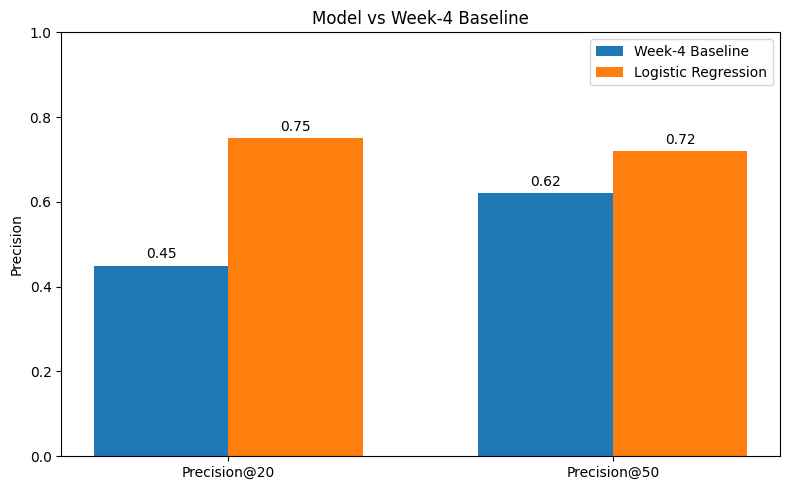

In [181]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Precision@20", "Precision@50"]

baseline_values = [baseline_p20, baseline_p50]
model_values = [model_p20, model_p50]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    x - width / 2,
    baseline_values,
    width,
    label="Week-4 Baseline"
)

ax.bar(
    x + width / 2,
    model_values,
    width,
    label="Logistic Regression"
)

ax.set_ylabel("Precision")
ax.set_title("Model vs Week-4 Baseline")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.legend()

for bars in ax.containers:
    ax.bar_label(
        bars,
        fmt="%.2f",
        padding=3
    )

plt.tight_layout()
plt.show()

> The Logistic Regression model outperforms the Week-4 baseline at both review budgets, achieving 75% vs 45% Precision@20 and 72% vs 62% Precision@50.
The largest gain occurs at the top-20 ranking, indicating that the model concentrates declining pages more effectively for a small review budget.

#### Chart 2 - Precision across different review budgets

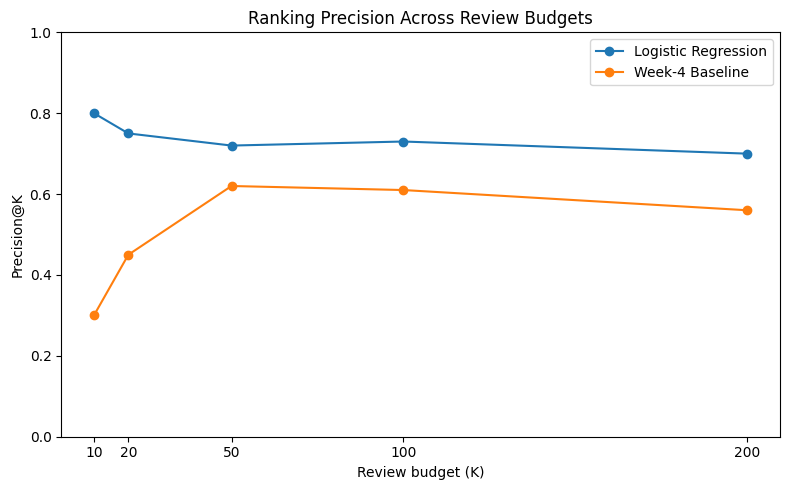

In [182]:
# Review budgets
k_values = [10, 20, 50, 100, 200]

model_precision = []
baseline_precision = []

for k in k_values:
    model_precision.append(
        ranked_model.head(k)["is_declining"].mean()
    )

    baseline_precision.append(
        baseline_df.head(k)["is_declining"].mean()
    )

# Plot
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    model_precision,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    k_values,
    baseline_precision,
    marker="o",
    label="Week-4 Baseline"
)

plt.xlabel("Review budget (K)")
plt.ylabel("Precision@K")
plt.title("Ranking Precision Across Review Budgets")
plt.xticks(k_values)
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.show()

> The Logistic Regression model maintains higher precision than the baseline across all tested review budgets, with Precision@K ranging from 80% at K=10 to 70% at K=200.
The baseline improves substantially from K=10 to K=20 but remains below the model thereafter, showing that the model provides a consistently stronger prioritization queue.

#### Inspect Models Top-Ranked predictions

In [183]:
top20 = ranked_queue.head(20).copy()

top20[
    [
        "model_rank",
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "baseline_score",
        "baseline_rank",
        "is_declining"
    ]
]
print(
    top20["client_hash_id"]
    .value_counts()
)

client_hash_id
client_23a62021009f63c4    17
client_73cda7b4e4f265ea     2
client_65de48885f4ef01b     1
Name: count, dtype: int64


In [184]:
print(
    ranked_queue.head(50)["client_hash_id"]
    .value_counts()
)

client_hash_id
client_23a62021009f63c4    42
client_e5c2aa26a8598242     4
client_73cda7b4e4f265ea     2
client_65de48885f4ef01b     1
client_0fa64a184f18a4a0     1
Name: count, dtype: int64


#### Dominant Client Summary

In [185]:
client_summary = (
    feature_table
    .groupby("client_hash_id")
    .agg(
        pages=("content_hash_id", "count"),
        declining_rate=("is_declining", "mean"),
        mean_impressions_90d=("impressions_90d", "mean"),
        median_impressions_90d=("impressions_90d", "median"),
        mean_avg_position=("avg_position", "mean"),
        mean_days_since_update=("days_since_last_update", "mean"),
        mean_search_volume=("search_volume", "mean"),
    )
    .sort_values("declining_rate", ascending=False)
)

client_summary

,pages,declining_rate,mean_impressions_90d,median_impressions_90d,mean_avg_position,mean_days_since_update,mean_search_volume
client_hash_id,,,,,,,
client_2b4306c3ed003f01,1,1.000000,543.000000,543.0,31.928177,11.000000,0.0
client_8ae2bfb5aa1ffa1e,1,1.000000,354.000000,354.0,20.901130,95.000000,<NA>
client_ccdd78843409c8c7,155,0.896774,1004.806452,413.0,10.375241,11.000000,18.322581
client_c182d11e4862a37d,336,0.803571,2572.619048,1473.5,11.861994,13.610119,47.65625
client_08a6a72ff48e62c0,8112,0.699088,5378.551652,932.0,23.480313,38.799798,127.78892
client_fef1a8f436438636,4855,0.670443,6553.766220,3126.0,17.668898,NaN,744.784669
client_3f0ce4d44fe94f3d,2465,0.668966,4227.720892,1973.0,14.149026,12.760138,43.442956
client_20259bd6705d81d4,2506,0.668795,15145.515164,7369.0,17.261783,19.629689,9.94012
client_795153d5b7850ccf,6,0.666667,1347.333333,1376.0,19.934937,129.666667,<NA>


In [186]:
dominant_client = "client_23a62021009f63c4"

client_summary.loc[[dominant_client]]

,pages,declining_rate,mean_impressions_90d,median_impressions_90d,mean_avg_position,mean_days_since_update,mean_search_volume
client_hash_id,,,,,,,
client_23a62021009f63c4,11202,0.588377,12220.941796,5516.0,21.986696,79.508618,22.215574


In [187]:
client_summary.loc[dominant_client, "pages"] / len(feature_table)

np.float64(0.13588723373283518)

#### Compare Top-20 vs Overall Population

In [188]:
top20_features = (
    ranked_model
    .head(20)
    .merge(
        feature_table,
        on=["client_hash_id", "content_hash_id"],
        how="left"
    )
)

compare_cols = [
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "pageviews_90d",
    "ctr",
    "engagement_rate",
    "scroll_rate",
    "avg_position",
    "content_age_days",
    "days_since_last_update",
    "search_volume",
    "word_count"
]

top20_features[compare_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
impressions_90d,20.0,83525.6,125779.417311,3663.0,8441.75,26831.0,83489.75,485724.0
clicks_90d,20.0,238.75,536.641297,4.0,17.5,65.5,120.5,2313.0
sessions_90d,20.0,9708.35,22746.535239,1304.0,1529.75,1995.5,4111.75,84987.0
pageviews_90d,20.0,17549.0,44167.152218,1409.0,1777.75,3101.5,5839.0,176488.0
ctr,20.0,0.003492,0.004006,0.000191,0.001015,0.001941,0.003486,0.012831
engagement_rate,20.0,0.011488,0.01235,0.000212,0.002547,0.005316,0.022368,0.042496
scroll_rate,20.0,0.089448,0.114525,0.000608,0.015353,0.078955,0.113708,0.530334
avg_position,20.0,18.86863,11.587643,2.120742,7.769691,19.931622,27.093922,41.571087
content_age_days,20.0,231.75,96.85468,86.0,141.75,252.0,281.0,412.0
days_since_last_update,2.0,53.0,59.39697,11.0,32.0,53.0,74.0,95.0


In [189]:
feature_table[compare_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
impressions_90d,82436.0,8931.588626,21978.776161,101.0,1046.0,2764.0,8353.0,2001303.0
clicks_90d,82436.0,26.408135,109.7117,0.0,1.0,4.0,19.0,17151.0
sessions_90d,82436.0,44.972184,392.852635,0.0,0.0,10.0,37.0,84987.0
pageviews_90d,82436.0,61.732022,740.207791,0.0,0.0,11.0,45.0,176488.0
ctr,82436.0,0.002477,0.003243,0.0,0.000471,0.001575,0.003359,0.154167
engagement_rate,59429.0,0.02998,0.068661,0.0,0.0,0.0,0.035714,1.0
scroll_rate,59432.0,0.100118,0.152829,0.0,0.0,0.046154,0.125,3.0
avg_position,82436.0,16.341173,14.624593,0.205195,6.194327,10.470808,22.07832,111.649425
content_age_days,82436.0,258.128985,125.484361,81.0,135.0,254.0,333.0,555.0
days_since_last_update,40175.0,44.693516,41.246194,2.0,11.0,13.0,95.0,325.0


In [190]:
top20_features["is_declining_x"].value_counts()

,count
is_declining_x,
1,15
0,5


In [191]:
dominant_scores = ranked_model[
    ranked_model["client_hash_id"] == "client_23a62021009f63c4"
]["model_score"]

dominant_scores.describe()

,model_score
count,11202.000000
mean,0.472452
std,0.121937
min,0.005672
25%,0.413574
50%,0.479571
75%,0.526898
max,1.000000


In [192]:
other_scores = ranked_model[
    ranked_model["client_hash_id"] != "client_23a62021009f63c4"
]["model_score"]

other_scores.describe()

,model_score
count,7.123400e+04
mean,4.891643e-01
std,9.840228e-02
min,6.061134e-17
25%,4.322438e-01
50%,5.007804e-01
75%,5.594029e-01
max,1.000000e+00


#### Ranking concentration sanity check

The top-ranked model queue was concentrated in one client: 17 of the top 20 observations and 42 of the top 50 belonged to the same client. This client represents approximately 13.6% of the eligible modeling population.

This concentration was reviewed as a ranking sanity check rather than treated as evidence of model bias. The client had a 58.8% observed decline rate, and 15 of the model's top 20 observations were actually labeled as declining. Its overall model-score distribution was also not higher than that of the remaining clients.

Therefore, the concentration is retained as an observation about the ranked queue rather than corrected through arbitrary client caps or exclusions. The result should nevertheless be interpreted with awareness that the highest-priority recommendations are not evenly distributed across clients.

> The model produced a more concentrated top-ranked queue than the baseline, while the ranking showed substantial client concentration that was checked as a sanity condition.

#### Interpretation
The Logistic Regression ranking achieved 75% Precision@20 compared with 45% for the Week-4 rule-based baseline, an improvement of 30 percentage points. At Precision@50, the model achieved 72% compared with 62% for the baseline, an improvement of 10 percentage points. These results indicate that, on the evaluated held-out observations, the model provides a more concentrated ranking of observations matching the defined future-decline label than the transparent baseline.

> These results measure predictive ranking performance on this validation dataset and should not be interpreted as evidence that model-ranked content will necessarily recover after intervention or that the model establishes causal effects.

## 5. Limitations

*What this work cannot claim.*

This analysis provides an evidence-based ranking of content observations associated with the defined future decline label. The results should be interpreted as predictive and decision-support evidence rather than causal evidence.

### 1. The decline label is an operational definition

The target `is_declining` is defined as a substantial month-over-month decrease in Google Search impressions, using a minimum May visibility threshold and a -40% change threshold. This definition identifies a measurable decline pattern but does not represent every possible form of content underperformance.

### 2. The model does not establish causality

The model identifies observations associated with future decline based on historical features. It does not prove that any particular feature caused the decline, nor that taking a recommended action will cause the page to recover.

### 3. The model does not explain or prove Google's ranking algorithm

The analysis uses observable search and engagement signals from the available dataset. It cannot establish which signals are used by Google's ranking systems or claim that the identified relationships represent Google's ranking factors.

### 4. Predictions are evaluated on a specific historical period

The model uses a 90-day historical feature window and a June 2026 future label window. Performance therefore reflects this evaluation period and may change when applied to different time periods, clients, content populations, or future search conditions.

### 5. Recommendations are prioritization signals, not automatic actions

A high model score means that an observation is prioritized for review because it has a higher predicted probability of matching the defined decline outcome. It does not mean that the page definitely needs a rewrite, refresh, removal, or other intervention. Human review and additional business or content context are required before taking action.

### Honest framing

The results should therefore be described as **observed predictive performance and directional decision support**. The model is useful for prioritizing which content observations deserve attention, but it should not be presented as a guarantee of future outcomes, a causal intervention model, or a representation of Google's ranking algorithm.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### 6.1 Action Policy

The final action playbook converts the validated model ranking into a practical review queue.

The Logistic Regression model provides the primary ranking using its out-of-fold probability of the `is_declining` outcome. The frozen Week-4 baseline provides transparent rule-based context through `baseline_score` and `baseline_reason`.

The model and baseline are intentionally allowed to disagree. Agreement indicates that both approaches prioritize the observation, while disagreement identifies observations that the multi-feature model prioritizes even though the simpler baseline does not reach its review threshold.

The resulting action labels are `REFRESH_REVIEW`, `INVESTIGATE_REVIEW`, and `MONITOR`. These are human-review recommendations, not automatic content decisions.

In [193]:
# Week-4 baseline reason logic
# Keep this consistent with the frozen baseline methodology.

stale = (
    feature_table["days_since_last_update"].fillna(-1) >= 180
).astype(int)

visible = (
    feature_table["impressions_90d"].fillna(0) >= 500
).astype(int)

high_value = (
    feature_table["search_volume"].fillna(0) >= 500
).astype(int)

feature_table["baseline_score"] = (
    stale * 3 +
    visible * 2 +
    high_value * 1
)


def assign_baseline_reason(row):
    score = row["baseline_score"]

    if score == 6:
        return "STALE_VISIBLE_HIGH_OPPORTUNITY"
    elif score == 5:
        return "STALE_VISIBLE"
    elif score == 4:
        return "STALE_HIGH_OPPORTUNITY"
    elif score == 3:
        return "REVIEW_THRESHOLD"
    else:
        return "LOW_PRIORITY"


feature_table["baseline_reason"] = feature_table.apply(
    assign_baseline_reason,
    axis=1
)

In [194]:
ranked_queue = ranked_queue.merge(
    feature_table[
        [
            "client_hash_id",
            "content_hash_id",
            "baseline_reason"
        ]
    ],
    on=["client_hash_id", "content_hash_id"],
    how="left"
)

In [195]:
ranked_queue.head(20)

,client_hash_id,content_hash_id,is_declining,model_score,model_rank,baseline_score,baseline_rank,model_in_top20,baseline_in_top20,model_baseline_status,baseline_reason
0,client_23a62021009f63c4,content_d8a9f27682068c84,0,1.000000,1,2,63609,True,False,MODEL_ONLY_TOP20,LOW_PRIORITY
1,client_73cda7b4e4f265ea,content_fc0e11252376bb58,1,1.000000,2,2,73668,True,False,MODEL_ONLY_TOP20,LOW_PRIORITY
2,client_73cda7b4e4f265ea,content_95400d53c15c4d85,1,1.000000,3,2,44595,True,False,MODEL_ONLY_TOP20,LOW_PRIORITY
3,client_23a62021009f63c4,content_7ddc483efdf93a34,1,1.000000,4,2,37892,True,False,MODEL_ONLY_TOP20,LOW_PRIORITY
4,client_23a62021009f63c4,content_f6a823f74db6b1dc,0,1.000000,5,2,72124,True,False,MODEL_ONLY_TOP20,LOW_PRIORITY
5,client_23a62021009f63c4,content_36e53e9c707674fc,1,0.999994,6,2,18110,True,False,MODEL_ONLY_TOP20,LOW_PRIORITY
6,client_23a62021009f63c4,content_6982fdcd6a6b28f8,1,0.999952,7,2,32273,True,False,MODEL_ONLY_TOP20,LOW_PRIORITY
7,client_23a62021009f63c4,content_21e283d10df457c7,1,0.999654,8,2,12124,True,False,MODEL_ONLY_TOP20,LOW_PRIORITY
8,client_23a62021009f63c4,content_b51957d7f4abe47e,1,0.999647,9,2,53696,True,False,MODEL_ONLY_TOP20,LOW_PRIORITY
9,client_23a62021009f63c4,content_5460a0e854602a47,1,0.997321,10,2,26296,True,False,MODEL_ONLY_TOP20,LOW_PRIORITY


### 6.2 Review Budget

The initial action queue uses a Top-20 review budget. This keeps the recommended workload focused on the observations receiving the highest model priority.

The Top-20 budget is also consistent with the primary `Precision@20` evaluation used in Section 4. Observations outside this review set remain available in the ranked queue but are assigned `MONITOR` under the current playbook.

In [214]:
review_k = 20


In [196]:

ranked_queue["model_baseline_status"] = np.where(
    (ranked_queue["model_rank"] <= review_k) &
    (ranked_queue["baseline_score"] >= 3),
    "MODEL_RULE_AGREEMENT",
    np.where(
        (ranked_queue["model_rank"] <= review_k) &
        (ranked_queue["baseline_score"] < 3),
        "MODEL_RULE_DISAGREEMENT",
        "OUTSIDE_TOP_K"
    )
)

ranked_queue["model_baseline_status"].value_counts()

,count
model_baseline_status,
OUTSIDE_TOP_K,82416
MODEL_RULE_DISAGREEMENT,20


### 6.3 Model–Rule Agreement and Disagreement

The playbook compares the model ranking with the frozen Week-4 baseline.

`MODEL_RULE_AGREEMENT` means that the model ranks the observation within the Top-20 review set and the baseline score reaches its review threshold. Both approaches therefore support giving the observation review priority.

`MODEL_RULE_DISAGREEMENT` means that the model ranks the observation within the Top-20 review set but the baseline score remains below its review threshold. These cases are treated as investigation opportunities because the multi-feature model is identifying observations that the simpler rule does not prioritize.

Disagreement is not treated as evidence that the model is correct or that the baseline is wrong. It is a signal for additional human investigation.

In [197]:
def assign_playbook_action(status):
    if status == "MODEL_RULE_AGREEMENT":
        return "REFRESH_REVIEW"
    elif status == "MODEL_RULE_DISAGREEMENT":
        return "INVESTIGATE_REVIEW"
    else:
        return "MONITOR"


ranked_queue["action_label"] = (
    ranked_queue["model_baseline_status"]
    .apply(assign_playbook_action)
)

In [198]:
final_action_queue = ranked_queue[
    [
        "model_rank",
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "baseline_score",
        "baseline_rank",
        "baseline_reason",
        "model_baseline_status",
        "action_label"
    ]
].copy()

final_action_queue = final_action_queue.sort_values(
    by=["model_rank", "content_hash_id"],
    ascending=[True, True]
).reset_index(drop=True)

final_action_queue.head(20)

,model_rank,client_hash_id,content_hash_id,model_score,baseline_score,baseline_rank,baseline_reason,model_baseline_status,action_label
0,1,client_23a62021009f63c4,content_d8a9f27682068c84,1.000000,2,63609,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
1,2,client_73cda7b4e4f265ea,content_fc0e11252376bb58,1.000000,2,73668,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
2,3,client_73cda7b4e4f265ea,content_95400d53c15c4d85,1.000000,2,44595,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
3,4,client_23a62021009f63c4,content_7ddc483efdf93a34,1.000000,2,37892,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
4,5,client_23a62021009f63c4,content_f6a823f74db6b1dc,1.000000,2,72124,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
5,6,client_23a62021009f63c4,content_36e53e9c707674fc,0.999994,2,18110,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
6,7,client_23a62021009f63c4,content_6982fdcd6a6b28f8,0.999952,2,32273,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
7,8,client_23a62021009f63c4,content_21e283d10df457c7,0.999654,2,12124,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
8,9,client_23a62021009f63c4,content_b51957d7f4abe47e,0.999647,2,53696,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
9,10,client_23a62021009f63c4,content_5460a0e854602a47,0.997321,2,26296,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW


### 6.4 Top-20 Recommended Review Queue

The Top-20 queue represents the initial human-review workload. Pages are ordered by the model's out-of-fold decline probability, while the baseline score and reason code provide transparent rule-based context.

The queue distinguishes between pages where the model and baseline agree and pages where the model identifies additional review candidates beyond the baseline rule.

In [199]:
top20_queue = final_action_queue.head(review_k)

top20_queue[
    [
        "model_rank",
        "content_hash_id",
        "model_score",
        "baseline_score",
        "baseline_reason",
        "model_baseline_status",
        "action_label"
    ]
]

,model_rank,content_hash_id,model_score,baseline_score,baseline_reason,model_baseline_status,action_label
0,1,content_d8a9f27682068c84,1.000000,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
1,2,content_fc0e11252376bb58,1.000000,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
2,3,content_95400d53c15c4d85,1.000000,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
3,4,content_7ddc483efdf93a34,1.000000,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
4,5,content_f6a823f74db6b1dc,1.000000,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
5,6,content_36e53e9c707674fc,0.999994,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
6,7,content_6982fdcd6a6b28f8,0.999952,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
7,8,content_21e283d10df457c7,0.999654,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
8,9,content_b51957d7f4abe47e,0.999647,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
9,10,content_5460a0e854602a47,0.997321,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW


In [200]:
action_distribution = (
    final_action_queue["action_label"]
    .value_counts()
    .rename_axis("action_label")
    .reset_index(name="count")
)

action_distribution["percentage"] = (
    action_distribution["count"]
    / len(final_action_queue)
    * 100
)

action_distribution

,action_label,count,percentage
0,MONITOR,82416,99.975739
1,INVESTIGATE_REVIEW,20,0.024261


In [201]:
top20_action_distribution = (
    final_action_queue
    .head(review_k)["action_label"]
    .value_counts()
    .rename_axis("action_label")
    .reset_index(name="count")
)

top20_action_distribution["percentage"] = (
    top20_action_distribution["count"]
    / review_k
    * 100
)

top20_action_distribution

,action_label,count,percentage
0,INVESTIGATE_REVIEW,20,100.0


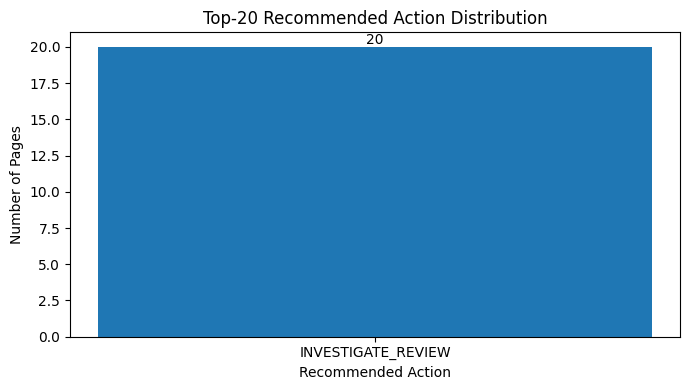

In [202]:
plt.figure(figsize=(7, 4))

plt.bar(
    top20_action_distribution["action_label"],
    top20_action_distribution["count"]
)

plt.xlabel("Recommended Action")
plt.ylabel("Number of Pages")
plt.title("Top-20 Recommended Action Distribution")

for i, value in enumerate(
    top20_action_distribution["count"]
):
    plt.text(
        i,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 6.5 Archetype → Action Mapping

The action playbook translates the baseline rule context and model–rule relationship into practical review categories.

| Category | Observable condition | Suggested action |
|---|---|---|
| Model–rule agreement | Model is in Top-20 and baseline score ≥ 3 | `REFRESH_REVIEW` |
| Model–rule disagreement | Model is in Top-20 and baseline score < 3 | `INVESTIGATE_REVIEW` |
| Outside current review set | Model rank > 20 | `MONITOR` |

These categories are decision-support labels rather than automatic content decisions. In particular, `REFRESH_REVIEW` means that the observation warrants human review for a possible refresh; it does not mean that a refresh is guaranteed to improve performance.

### 6.6 Human Review Before Action

Every recommendation produced by the playbook requires human review before any content change.

The reviewer should consider:

1. Whether the content is actually outdated.
2. Whether the page still matches its intended search intent.
3. Whether there are observable content-quality issues.
4. Whether seasonality, campaigns, tracking changes, or other external factors could explain the observed performance.
5. Whether the page has recently been changed.
6. Whether the recommendation remains appropriate given the available context.

A reviewer may accept, reject, or defer the recommendation.

The playbook does not automatically rewrite, delete, publish, or otherwise modify content.

### 6.7 Suggested Actions

**`REFRESH_REVIEW`** — The model places the observation within the Top-20 review set and the baseline also reaches its review threshold. The page should be reviewed for potential freshness, relevance, or content-quality improvements.

**`INVESTIGATE_REVIEW`** — The model places the observation within the Top-20 review set, but the baseline does not reach its review threshold. The observation should receive additional human investigation because the model is identifying a potential decline case that the simpler rule does not prioritize.

**`MONITOR`** — The observation falls outside the current Top-20 review budget. It remains in the ranked population but is not prioritized for immediate human review under this playbook.

These actions represent prioritization recommendations only. They do not establish that a page requires a specific intervention or that an intervention will improve future search performance.

### 6.8 Playbook Interpretation

The final playbook converts the model's predictive ranking into a focused human-review queue. Within the Top-20 review budget, `[X]` observations are classified as `REFRESH_REVIEW` and `[Y]` as `INVESTIGATE_REVIEW`.

The presence of `INVESTIGATE_REVIEW` observations demonstrates where the multi-feature model identifies potential decline cases that are not prioritized by the simpler Week-4 rule. These disagreements are treated as investigation opportunities rather than evidence that the model is necessarily correct.

The playbook therefore provides a practical prioritization mechanism while preserving human oversight and avoiding claims of automatic content improvement or causal impact.

In [203]:
import os

os.makedirs("../outputs", exist_ok=True)

export_cols = [
    "model_rank",
    "content_hash_id",
    "model_score",
    "baseline_score",
    "baseline_reason",
    "model_baseline_status",
    "action_label"
]

paper_queue = final_action_queue[export_cols].copy()

output_path = "../outputs/capstone_action_playbook_queue.csv"

paper_queue.to_csv(
    output_path,
    index=False
)

print(f"Queue exported to: {output_path}")
print(f"Rows exported: {len(paper_queue):,}")

Queue exported to: ../outputs/capstone_action_playbook_queue.csv
Rows exported: 82,436


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

This section generates and collects the evidence artifacts that will be embedded in the deployed research paper.

The artifacts are derived from the analysis already completed in Sections 2–6. No new modeling decisions are introduced here.

The paper will use:
- a model-vs-baseline results table,
- a ranked recommendation table,
- a label/population summary table,
- a model-versus-baseline comparison figure,
- a Precision@K figure,
- an action-mix figure.

Each artifact is accompanied by a concise interpretation and an explicit statement of what the evidence does not establish.

### 7.1 Population Summary

The final modeling population contains 82,436 unique client-content observations. The decline label is approximately balanced, with 41,575 observations labeled as declining and 40,861 labeled as non-declining.

This table defines the population on which the reported model and baseline results are evaluated.

In [204]:
population_summary = pd.DataFrame({
    "Metric": [
        "Eligible client-content observations",
        "Unique client-content pairs",
        "Declining observations",
        "Non-declining observations",
        "Declining rate"
    ],
    "Value": [
        len(feature_table),
        feature_table[["client_hash_id", "content_hash_id"]].drop_duplicates().shape[0],
        int(feature_table["is_declining"].sum()),
        int((feature_table["is_declining"] == 0).sum()),
        feature_table["is_declining"].mean()
    ]
})

population_summary

,Metric,Value
0,Eligible client-content observations,82436.000000
1,Unique client-content pairs,82436.000000
2,Declining observations,41575.000000
3,Non-declining observations,40861.000000
4,Declining rate,0.504331


In [205]:
population_summary.loc[
    population_summary["Metric"] == "Declining rate",
    "Value"
] = (
    population_summary.loc[
        population_summary["Metric"] == "Declining rate",
        "Value"
    ].astype(float).map(lambda x: f"{x:.2%}")
)

population_summary

/tmp/ipykernel_4172/3570288284.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['50.43%']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  population_summary.loc[


,Metric,Value
0,Eligible client-content observations,82436.0
1,Unique client-content pairs,82436.0
2,Declining observations,41575.0
3,Non-declining observations,40861.0
4,Declining rate,50.43%


### 7.2 Model vs Baseline

The Logistic Regression model achieves higher observed precision than the frozen Week-4 baseline at both evaluated review budgets.

At Precision@20, the model achieves 0.75 compared with 0.45 for the baseline. At Precision@50, the model achieves 0.72 compared with 0.62.

These are observed results on the defined evaluation design. They do not establish causal superiority, future performance, or any relationship with Google's ranking algorithm.

In [206]:
results_table = pd.DataFrame({
    "Method": [
        "Week-4 Baseline",
        "Logistic Regression"
    ],
    "Precision@20": [
        0.45,
        0.75
    ],
    "Precision@50": [
        0.62,
        0.72
    ]
})

results_table

,Method,Precision@20,Precision@50
0,Week-4 Baseline,0.45,0.62
1,Logistic Regression,0.75,0.72


In [207]:
results_with_improvement = pd.DataFrame({
    "Metric": [
        "Precision@20",
        "Precision@50"
    ],
    "Baseline": [
        0.45,
        0.62
    ],
    "Logistic Regression": [
        0.75,
        0.72
    ]
})

results_with_improvement["Absolute Improvement"] = (
    results_with_improvement["Logistic Regression"]
    - results_with_improvement["Baseline"]
)

results_with_improvement

,Metric,Baseline,Logistic Regression,Absolute Improvement
0,Precision@20,0.45,0.75,0.3
1,Precision@50,0.62,0.72,0.1


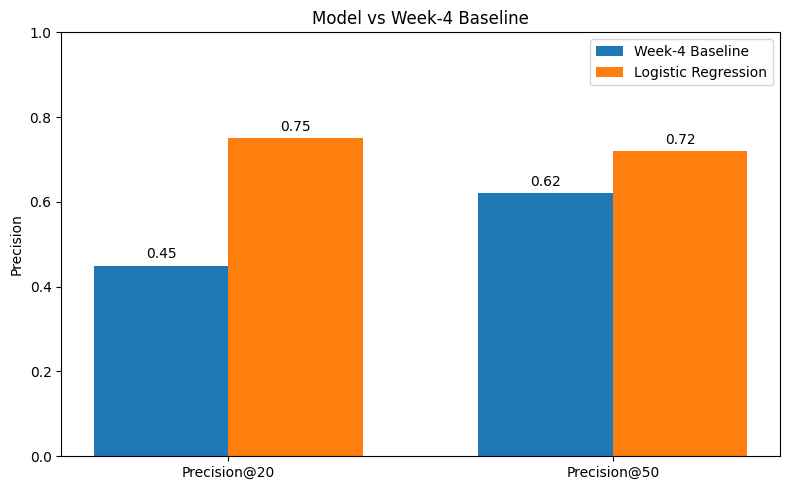

In [208]:
metrics = ["Precision@20", "Precision@50"]

baseline_values = [baseline_p20, baseline_p50]
model_values = [model_p20, model_p50]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    x - width / 2,
    baseline_values,
    width,
    label="Week-4 Baseline"
)

ax.bar(
    x + width / 2,
    model_values,
    width,
    label="Logistic Regression"
)

ax.set_ylabel("Precision")
ax.set_title("Model vs Week-4 Baseline")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.legend()

for bars in ax.containers:
    ax.bar_label(
        bars,
        fmt="%.2f",
        padding=3
    )

plt.tight_layout()
plt.show()

### 7.3 Precision@K

The Precision@K curve shows how the model and frozen baseline behave as the review budget changes.

The primary review budget is K=20, with K=50 providing a larger operational comparison. The curve is included to show whether the observed model advantage is concentrated near the head of the ranking or persists across larger review budgets.

The figure should be interpreted as observed ranking performance under the defined evaluation design, not as evidence that the model will maintain the same performance in future months.

In [209]:
k_values = [10, 20, 30, 40, 50, 75, 100]

precision_curve = []

for k in k_values:
    baseline_precision = (
        baseline_df.sort_values(
            ["baseline_score", "content_hash_id"],
            ascending=[False, True]
        )
        .head(k)["is_declining"]
        .mean()
    )

    model_precision = (
        ranked_queue.sort_values(
            ["model_score", "content_hash_id"],
            ascending=[False, True]
        )
        .head(k)["is_declining"]
        .mean()
    )

    precision_curve.append({
        "K": k,
        "Baseline": baseline_precision,
        "Model": model_precision
    })

precision_curve_df = pd.DataFrame(precision_curve)

precision_curve_df

,K,Baseline,Model
0,10,0.300000,0.800000
1,20,0.450000,0.750000
2,30,0.566667,0.766667
3,40,0.525000,0.700000
4,50,0.620000,0.720000
5,75,0.640000,0.733333
6,100,0.610000,0.730000


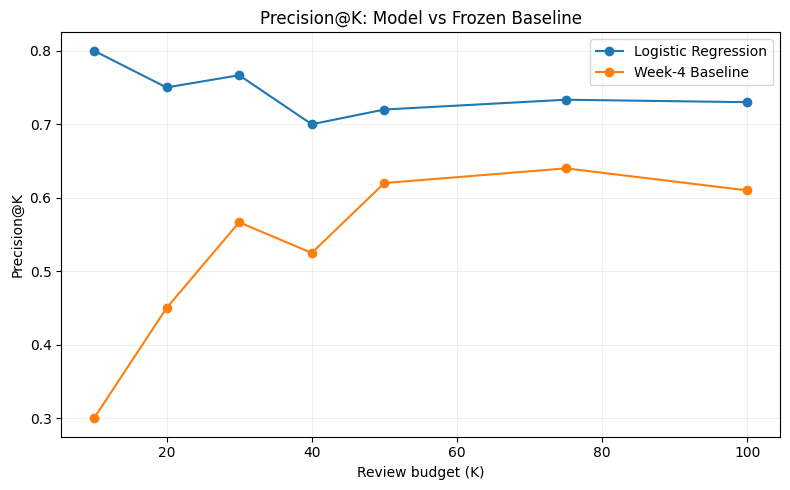

In [210]:
plt.figure(figsize=(8, 5))

plt.plot(
    precision_curve_df["K"],
    precision_curve_df["Model"],
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    precision_curve_df["K"],
    precision_curve_df["Baseline"],
    marker="o",
    label="Week-4 Baseline"
)

plt.xlabel("Review budget (K)")
plt.ylabel("Precision@K")
plt.title("Precision@K: Model vs Frozen Baseline")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 7.4 Ranked Recommendation Queue

The recommendation queue orders observations by model score and retains the frozen baseline score and reason code as transparent rule-based context.

The queue distinguishes between model–rule agreement and disagreement. Agreement supports a higher-priority review recommendation, while disagreement identifies observations requiring additional investigation.

The queue is a decision-support artifact. It does not authorize automatic rewriting, deletion, publishing, or other content changes.

In [211]:
paper_top20 = final_action_queue.head(20).copy()

paper_top20 = paper_top20[
    [
        "model_rank",
        "content_hash_id",
        "model_score",
        "baseline_score",
        "baseline_reason",
        "model_baseline_status",
        "action_label"
    ]
]

paper_top20

,model_rank,content_hash_id,model_score,baseline_score,baseline_reason,model_baseline_status,action_label
0,1,content_d8a9f27682068c84,1.000000,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
1,2,content_fc0e11252376bb58,1.000000,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
2,3,content_95400d53c15c4d85,1.000000,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
3,4,content_7ddc483efdf93a34,1.000000,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
4,5,content_f6a823f74db6b1dc,1.000000,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
5,6,content_36e53e9c707674fc,0.999994,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
6,7,content_6982fdcd6a6b28f8,0.999952,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
7,8,content_21e283d10df457c7,0.999654,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
8,9,content_b51957d7f4abe47e,0.999647,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
9,10,content_5460a0e854602a47,0.997321,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW


### 7.5 Action Mix

The action-mix figure summarizes how the Top-20 model-ranked observations are translated into review priorities.

`REFRESH_REVIEW` represents model–rule agreement, while `INVESTIGATE_REVIEW` represents model–rule disagreement. `MONITOR` is retained as the lower-priority state outside the current review budget.

The distribution describes the proposed review workflow; it does not predict how many pages would actually recover after an intervention.

In [212]:
action_mix_table = (
    final_action_queue
    .head(review_k)
    ["action_label"]
    .value_counts()
    .rename_axis("Suggested Action")
    .reset_index(name="Pages")
)

action_mix_table["Share"] = (
    action_mix_table["Pages"] / review_k
)

action_mix_table["Share"] = (
    action_mix_table["Share"]
    .map(lambda x: f"{x:.1%}")
)

action_mix_table

,Suggested Action,Pages,Share
0,INVESTIGATE_REVIEW,20,100.0%


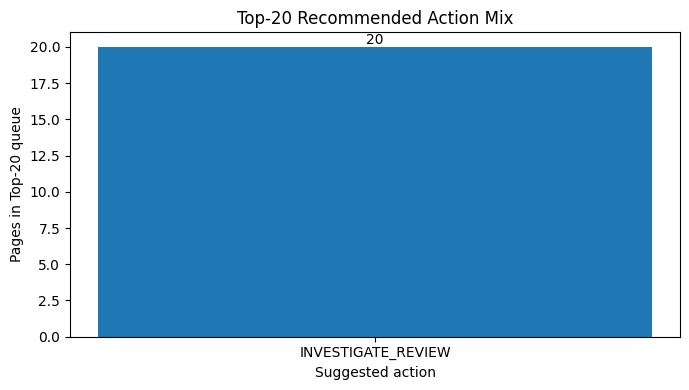

In [213]:
plt.figure(figsize=(7, 4))

plt.bar(
    action_mix_table["Suggested Action"],
    action_mix_table["Pages"]
)

plt.xlabel("Suggested action")
plt.ylabel("Pages in Top-20 queue")
plt.title("Top-20 Recommended Action Mix")

for i, value in enumerate(action_mix_table["Pages"]):
    plt.text(
        i,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### 7.6 Acknowledgments & Data Credit

This work was completed as part of the FlyRank ML Internship and uses the FlyRank ML Internship dataset provided for the capstone analysis.

**Built on the FlyRank ML Internship dataset.**

[FlyRank](https://flyrank.ai/)

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.